RFECV挑选了几个特征 : 5
特征：EVI, 得分：3.5245015577744203
特征：GNDVI, 得分：3.433903374474496
特征：NGRDI, 得分：3.410050656649793
特征：NPCI, 得分：3.385030293906534
特征：RVI, 得分：3.365003483159822


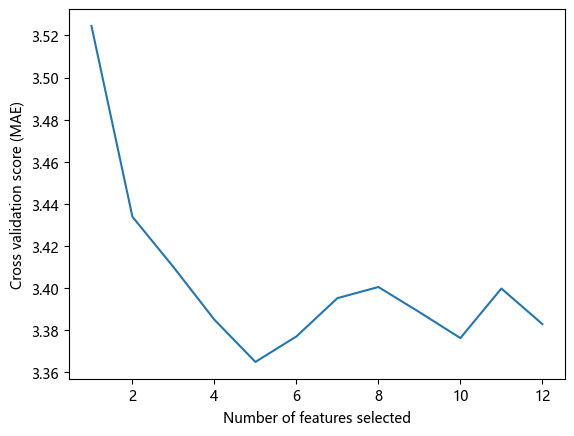

所选特征的名称: ['EVI', 'GNDVI', 'NGRDI', 'NPCI', 'RVI']
图形的数据: [(1, 3.5245015577744203), (2, 3.433903374474496), (3, 3.410050656649793), (4, 3.385030293906534), (5, 3.365003483159822), (6, 3.3770972938434896), (7, 3.3952741626086853), (8, 3.4005725060063505), (9, 3.3886334615298046), (10, 3.376320977011909), (11, 3.399853997427864), (12, 3.3829744871963983)]


In [5]:
#%%
#matplotlib是一个面向对象的绘图库；sklearn涵盖了分类、回归、聚类、降维、模型选择、数据预处理六大模块;
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification
import matplotlib #主要用来作图
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import RFE

matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文
dataset=pd.read_excel(r"E:\论文5\C\特征选择\UAV0610.xlsx")
dataset.head()
#print(dataset.isnull().sum())  # 检查空值
#print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf
z=6
#Build a classification task using 31 informative features       # 建立特征，X有31个特征，其中有效特征3个。
X, y = make_classification(n_samples=200, n_features=16, n_informative=6,n_redundant=8, n_repeated=0, n_classes=5, n_clusters_per_class=5, 
                           random_state=z)
X,y=dataset.iloc[:,:-1],dataset.iloc[:,-1]#可以表示x为除了最后一列，y为最后一列
#print(X,y)#输出表示x，y
#print("X维度", X.shape)
#print("y维度",y.shape)

#RFECV
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV

# 创建回归器(基于随机森林算法的特征选择方法)
rfr = RandomForestRegressor(n_estimators=53,
                              max_depth=3,
                              min_samples_split=2,
                              min_samples_leaf=1,
                              max_features=6, 
                              random_state=z)


# 使用 RFECV 进行特征筛选
rfecv = RFECV(estimator=rfr, step=1, cv=5, scoring='neg_mean_absolute_error')
rfecv.fit(X, y)

print("RFECV挑选了几个特征 : %d" % rfecv.n_features_)

# 画出不同特征数量下交叉认证验证得分
plt.figure()
# 选择的特征数量
plt.xlabel("Number of features selected")
# 交叉验证得分
plt.ylabel("Cross validation score (MAE)")
# 画出各个特征的得分
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), -rfecv.cv_results_['mean_test_score'])

# 输出每个特征及其对应的得分
selected_features = X.columns[rfecv.support_]
scores = -rfecv.cv_results_['mean_test_score']

for feature, score in zip(selected_features, scores):
    print(f"特征：{feature}, 得分：{score}")
plt.show()
#################保存到文件#########
#图形数据输出到指定文件
import pandas as pd

# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': selected_features, 'y_pred': score})
with pd.ExcelWriter(r"E:\论文5\C\训练集和测试集\递归特征结果0820.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)


# 输出所选特征集合名称
selected_features = X.columns[rfecv.support_]
print("所选特征的名称: {}".format(list(selected_features)))
# 输出每次交叉验证，每个特征的得分，即画上图的数据
data = list(zip(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), -rfecv.cv_results_['mean_test_score']))

df = pd.DataFrame({'y_test': data})
with pd.ExcelWriter(r"E:\论文5\C\训练集和测试集\递归特征过程0820.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

print("图形的数据: {}".format(data))

#%%

RFECV挑选了几个特征 : 5
特征：IPVI, 得分：0.017929287543248722
特征：NDVI, 得分：0.018540538178180084
特征：RDVI, 得分：0.0180733178426229
特征：RVI, 得分：0.017447435968983002
特征：VV, 得分：0.01736529380190696


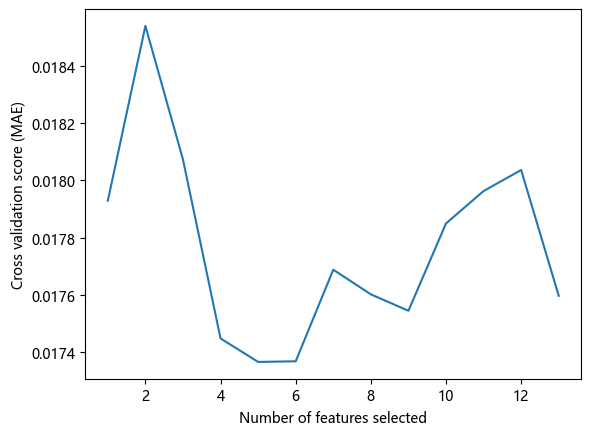

所选特征的名称: ['IPVI', 'NDVI', 'RDVI', 'RVI', 'VV']
图形的数据: [(1, 0.017929287543248722), (2, 0.018540538178180084), (3, 0.0180733178426229), (4, 0.017447435968983002), (5, 0.01736529380190696), (6, 0.017367524456066964), (7, 0.01768783975017538), (8, 0.017601655339755246), (9, 0.017544189030045666), (10, 0.01784967875028288), (11, 0.017963013364139864), (12, 0.018036536999175883), (13, 0.017596584882524847)]


In [385]:
#%%XGBoost
#matplotlib是一个面向对象的绘图库；sklearn涵盖了分类、回归、聚类、降维、模型选择、数据预处理六大模块;


from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import make_classification
import matplotlib #主要用来作图
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import RFE


import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time


matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文
dataset=pd.read_excel(r"E:\论文5\b\数据\0908\0908VI_30.xls")
dataset.head()
#print(dataset.isnull().sum())  # 检查空值
#print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf

#Build a classification task using 31 informative features       # 建立特征，X有31个特征，其中有效特征3个。
X, y = make_classification(n_samples=10, n_features=10, n_informative=5,n_redundant=2, n_repeated=0, n_classes=5, n_clusters_per_class=5, 
                           random_state=51)#121
X,y=dataset.iloc[:,:-1],dataset.iloc[:,-1]#可以表示x为除了最后一列，y为最后一列
#print(X,y)#输出表示x，y
#print("X维度", X.shape)
#print("y维度",y.shape)

#RFECV
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV

# 创建回归器(基于随机森林算法的特征选择方法)

# XGBoost回归模型#(min_child_weight：每个叶子节点的最小权重，可以降低树的复杂度，防止过拟合)#（ alpha：L1正则化，防止过拟合）,
rfr = xgb.XGBRegressor(n_estimators=51,
    max_depth=3,
    learning_rate=0.091,
    colsample_bytree=0.5,
    min_child_weight=3,
    reg_alpha=0.05,  # L1正则 0.4
    reg_lambda=0.3,  # L2正则
    subsample=0.6) # 新增行采样

# 使用 RFECV 进行特征筛选
rfecv = RFECV(estimator=rfr, step=1, cv=5, scoring='neg_mean_absolute_error')
rfecv.fit(X, y)

print("RFECV挑选了几个特征 : %d" % rfecv.n_features_)

# 画出不同特征数量下交叉认证验证得分
plt.figure()
# 选择的特征数量
plt.xlabel("Number of features selected")
# 交叉验证得分
plt.ylabel("Cross validation score (MAE)")
# 画出各个特征的得分
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), -rfecv.cv_results_['mean_test_score'])

# 输出每个特征及其对应的得分
selected_features = X.columns[rfecv.support_]
scores = -rfecv.cv_results_['mean_test_score']

for feature, score in zip(selected_features, scores):
    print(f"特征：{feature}, 得分：{score}")
plt.show()
#################保存到文件#########
#图形数据输出到指定文件
import pandas as pd

# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': selected_features, 'y_pred': score})
with pd.ExcelWriter(r"E:\论文5\b\数据\0908\递归特征结果T.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

# 输出所选特征集合名称
selected_features = X.columns[rfecv.support_]
print("所选特征的名称: {}".format(list(selected_features)))
# 输出每次交叉验证，每个特征的得分，即画上图的数据
data = list(zip(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), -rfecv.cv_results_['mean_test_score']))

df = pd.DataFrame({'y_test': data})
with pd.ExcelWriter(r"E:\论文5\b\数据\0908\递归特征结果T.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

print("图形的数据: {}".format(data))
#%%